In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm
import os
import re

PROJECT_DIR = Path("/content/drive/MyDrive/Underwater-Image-Data-set-main")

DAY2_DIR = PROJECT_DIR / "Day_2"
RESULTS_DIR = DAY2_DIR / "results"
SAMPLES_DIR = DAY2_DIR / "representative_samples"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

print("Day 2 output folder:")
print(DAY2_DIR)

Day 2 output folder:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day_2


In [3]:
image_files = []

for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
    image_files.extend(PROJECT_DIR.rglob(ext))

print("Total image files found:", len(image_files))

Total image files found: 4644


In [4]:
pattern = re.compile(
    r"img_(\d+)_(input|target|gen)",
    re.IGNORECASE
)

records = []

for path in image_files:
    match = pattern.fullmatch(path.stem)

    if match:
        image_id = int(match.group(1))
        category = match.group(2).lower()

        try:
            relative_parts = path.relative_to(PROJECT_DIR).parts

            # Find archive/source folder if possible
            source_archive = relative_parts[0]

        except:
            source_archive = "unknown"

        records.append({
            "file": str(path),
            "filename": path.name,
            "image_id": image_id,
            "category": category,
            "source_archive": source_archive
        })

df = pd.DataFrame(records)

print("Parsed images:", len(df))
print(df.head())

Parsed images: 942
                                                file            filename  \
0  /content/drive/MyDrive/Underwater-Image-Data-s...  img_123_target.png   
1  /content/drive/MyDrive/Underwater-Image-Data-s...     img_123_gen.png   
2  /content/drive/MyDrive/Underwater-Image-Data-s...   img_123_input.png   
3  /content/drive/MyDrive/Underwater-Image-Data-s...   img_135_input.png   
4  /content/drive/MyDrive/Underwater-Image-Data-s...     img_135_gen.png   

   image_id category     source_archive  
0       123   target  extracted_dataset  
1       123      gen  extracted_dataset  
2       123    input  extracted_dataset  
3       135    input  extracted_dataset  
4       135      gen  extracted_dataset  


In [5]:
quality_records = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    path = row["file"]

    try:
        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = float(np.mean(gray))
        contrast = float(np.std(gray))
        sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())

        height, width = gray.shape

        quality_records.append({
            "filename": row["filename"],
            "file": path,
            "image_id": row["image_id"],
            "category": row["category"],
            "source_archive": row["source_archive"],
            "width": width,
            "height": height,
            "brightness": brightness,
            "contrast": contrast,
            "sharpness": sharpness,
            "file_size_kb": os.path.getsize(path) / 1024
        })

    except Exception as e:
        pass

quality_df = pd.DataFrame(quality_records)

print("Images successfully analysed:", len(quality_df))
quality_df.head()

100%|██████████| 942/942 [02:29<00:00,  6.32it/s]

Images successfully analysed: 942


,filename,file,image_id,category,source_archive,width,height,brightness,contrast,sharpness,file_size_kb
0,img_123_target.png,/content/drive/MyDrive/Underwater-Image-Data-s...,123,target,extracted_dataset,256,256,99.366318,54.979199,469.672278,82.251953
1,img_123_gen.png,/content/drive/MyDrive/Underwater-Image-Data-s...,123,gen,extracted_dataset,256,256,94.073502,52.150722,545.878619,116.461914
2,img_123_input.png,/content/drive/MyDrive/Underwater-Image-Data-s...,123,input,extracted_dataset,256,256,141.594360,25.757902,51.127256,59.896484
3,img_135_input.png,/content/drive/MyDrive/Underwater-Image-Data-s...,135,input,extracted_dataset,256,256,131.982758,17.268098,47.827574,61.269531
4,img_135_gen.png,/content/drive/MyDrive/Underwater-Image-Data-s...,135,gen,extracted_dataset,256,256,102.635315,52.346229,365.886044,114.901367


In [6]:
quality_df.to_csv(
    RESULTS_DIR / "image_quality_statistics.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "image_quality_statistics.csv")

Saved: /content/drive/MyDrive/Underwater-Image-Data-set-main/Day_2/results/image_quality_statistics.csv


In [7]:
overall_stats = pd.DataFrame({
    "Metric": [
        "Total analysed images",
        "Mean brightness",
        "Median brightness",
        "Mean contrast",
        "Median contrast",
        "Mean sharpness",
        "Median sharpness",
        "Mean width",
        "Mean height",
        "Minimum width",
        "Maximum width",
        "Minimum height",
        "Maximum height"
    ],
    "Value": [
        len(quality_df),
        quality_df["brightness"].mean(),
        quality_df["brightness"].median(),
        quality_df["contrast"].mean(),
        quality_df["contrast"].median(),
        quality_df["sharpness"].mean(),
        quality_df["sharpness"].median(),
        quality_df["width"].mean(),
        quality_df["height"].mean(),
        quality_df["width"].min(),
        quality_df["width"].max(),
        quality_df["height"].min(),
        quality_df["height"].max()
    ]
})

display(overall_stats)

,Metric,Value
0,Total analysed images,942.000000
1,Mean brightness,154.102134
2,Median brightness,145.061020
3,Mean contrast,33.726824
4,Median contrast,27.280645
5,Mean sharpness,279.902593
6,Median sharpness,187.093240
7,Mean width,256.000000
8,Mean height,256.000000
9,Minimum width,256.000000


In [8]:
overall_stats.to_csv(
    RESULTS_DIR / "overall_image_statistics.csv",
    index=False
)

In [9]:
category_stats = (
    quality_df
    .groupby("category")
    .agg(
        image_count=("filename", "count"),
        mean_brightness=("brightness", "mean"),
        median_brightness=("brightness", "median"),
        mean_contrast=("contrast", "mean"),
        median_contrast=("contrast", "median"),
        mean_sharpness=("sharpness", "mean"),
        median_sharpness=("sharpness", "median"),
        mean_width=("width", "mean"),
        mean_height=("height", "mean")
    )
    .reset_index()
)

display(category_stats)

,category,image_count,mean_brightness,median_brightness,mean_contrast,median_contrast,mean_sharpness,median_sharpness,mean_width,mean_height
0,gen,314,152.100787,152.325897,42.619983,45.515397,295.255281,304.174519,256.0,256.0
1,input,314,157.052753,143.953339,13.492417,11.276946,27.353461,8.880672,256.0,256.0
2,target,314,153.152862,148.288132,45.068073,48.607562,517.099037,436.123840,256.0,256.0


In [10]:
category_stats.to_csv(
    RESULTS_DIR / "category_quality_statistics.csv",
    index=False
)

In [11]:
archive_distribution = (
    df.groupby(["source_archive", "category"])
      .size()
      .reset_index(name="image_count")
)

display(archive_distribution)

,source_archive,category,image_count
0,epoch_0096,gen,157
1,epoch_0096,input,157
2,epoch_0096,target,157
3,extracted_dataset,gen,157
4,extracted_dataset,input,157
5,extracted_dataset,target,157


In [12]:
archive_distribution.to_csv(
    RESULTS_DIR / "source_archive_distribution.csv",
    index=False
)

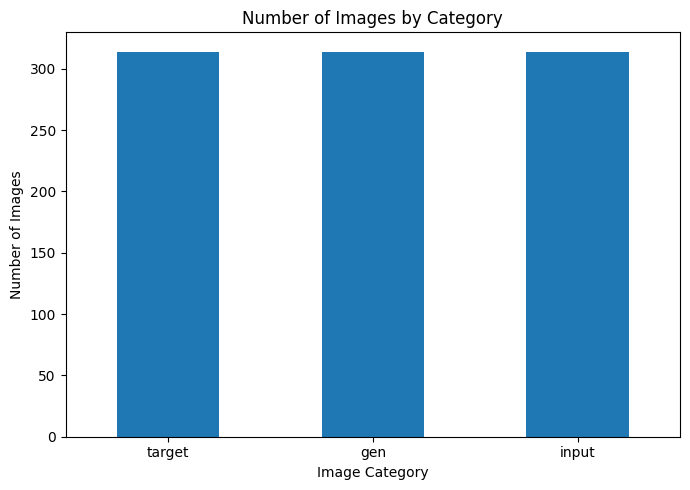

In [13]:
category_counts = df["category"].value_counts()

plt.figure(figsize=(7,5))

category_counts.plot(kind="bar")

plt.title("Number of Images by Category")
plt.xlabel("Image Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "category_distribution.png",
    dpi=200
)

plt.show()

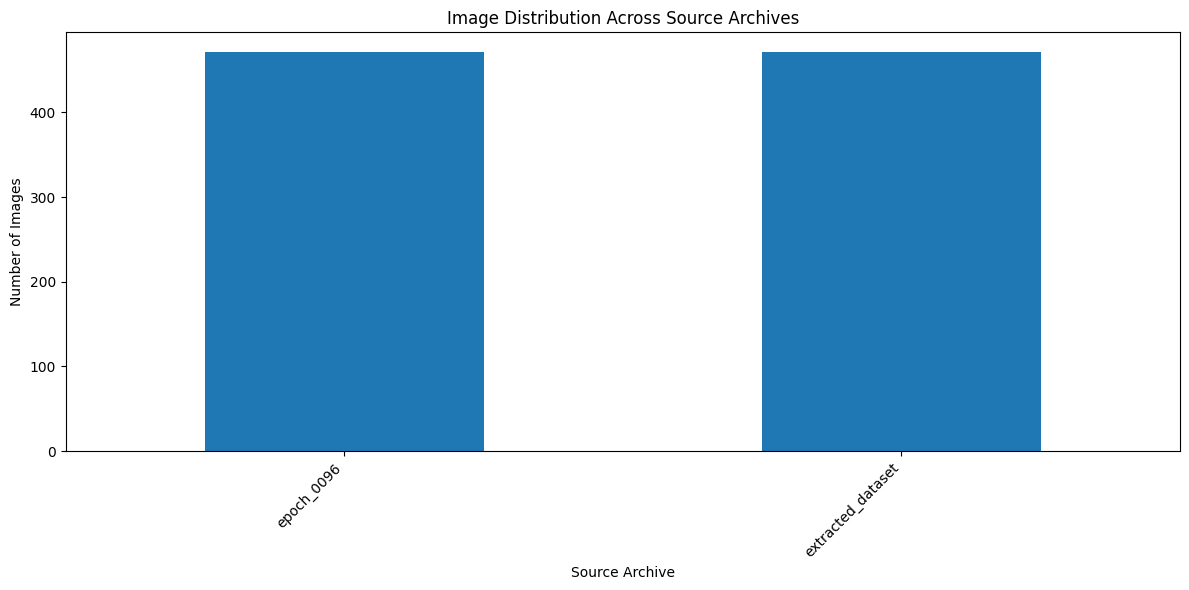

In [14]:
archive_counts = (
    df.groupby("source_archive")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

archive_counts.plot(kind="bar")

plt.title("Image Distribution Across Source Archives")
plt.xlabel("Source Archive")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "source_archive_distribution.png",
    dpi=200
)

plt.show()

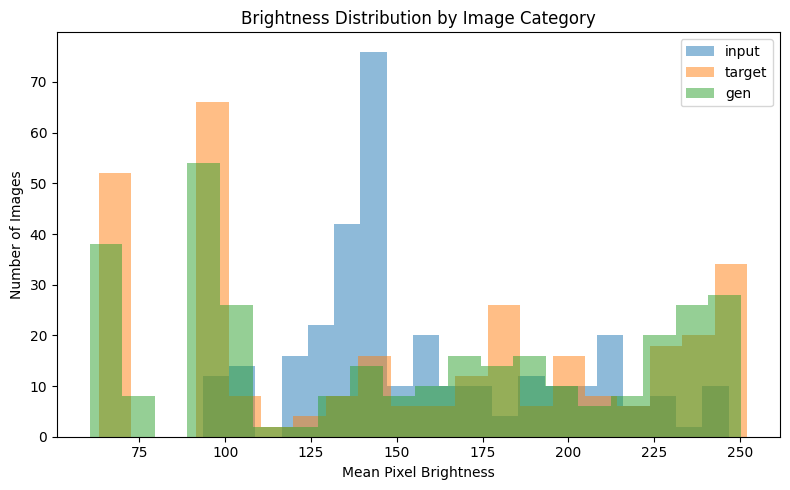

In [15]:
plt.figure(figsize=(8,5))

for category in ["input", "target", "gen"]:

    subset = quality_df[
        quality_df["category"] == category
    ]

    plt.hist(
        subset["brightness"],
        bins=20,
        alpha=0.5,
        label=category
    )

plt.title("Brightness Distribution by Image Category")
plt.xlabel("Mean Pixel Brightness")
plt.ylabel("Number of Images")
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "brightness_distribution_by_category.png",
    dpi=200
)

plt.show()

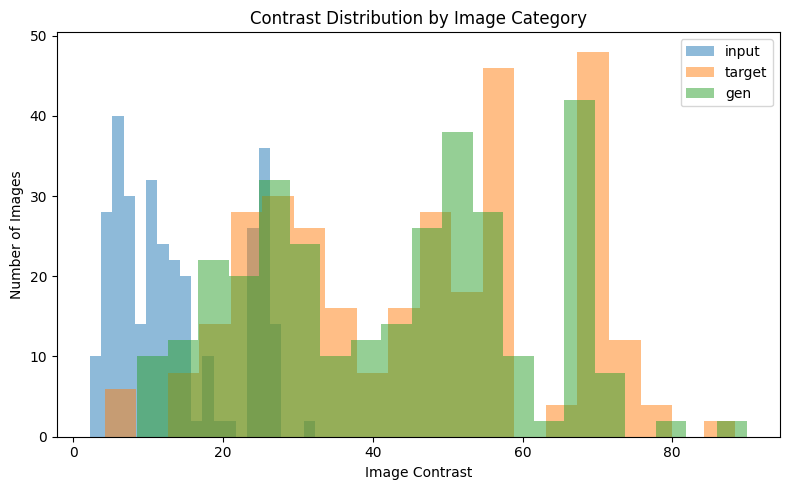

In [16]:
plt.figure(figsize=(8,5))

for category in ["input", "target", "gen"]:

    subset = quality_df[
        quality_df["category"] == category
    ]

    plt.hist(
        subset["contrast"],
        bins=20,
        alpha=0.5,
        label=category
    )

plt.title("Contrast Distribution by Image Category")
plt.xlabel("Image Contrast")
plt.ylabel("Number of Images")
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "contrast_distribution_by_category.png",
    dpi=200
)

plt.show()

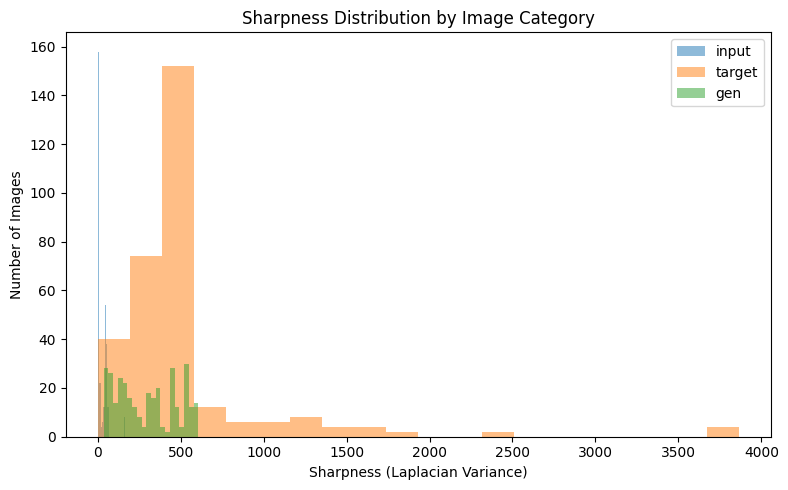

In [17]:
plt.figure(figsize=(8,5))

for category in ["input", "target", "gen"]:

    subset = quality_df[
        quality_df["category"] == category
    ]

    plt.hist(
        subset["sharpness"],
        bins=20,
        alpha=0.5,
        label=category
    )

plt.title("Sharpness Distribution by Image Category")
plt.xlabel("Sharpness (Laplacian Variance)")
plt.ylabel("Number of Images")
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "sharpness_distribution_by_category.png",
    dpi=200
)

plt.show()

In [18]:
sample_table = (
    df.pivot_table(
        index=["source_archive", "image_id"],
        columns="category",
        values="file",
        aggfunc="first"
    )
    .reset_index()
)

sample_table["complete"] = (
    sample_table["input"].notna() &
    sample_table["target"].notna() &
    sample_table["gen"].notna()
)

complete_samples = sample_table[
    sample_table["complete"]
].copy()

print("Complete triplets:", len(complete_samples))

Complete triplets: 314


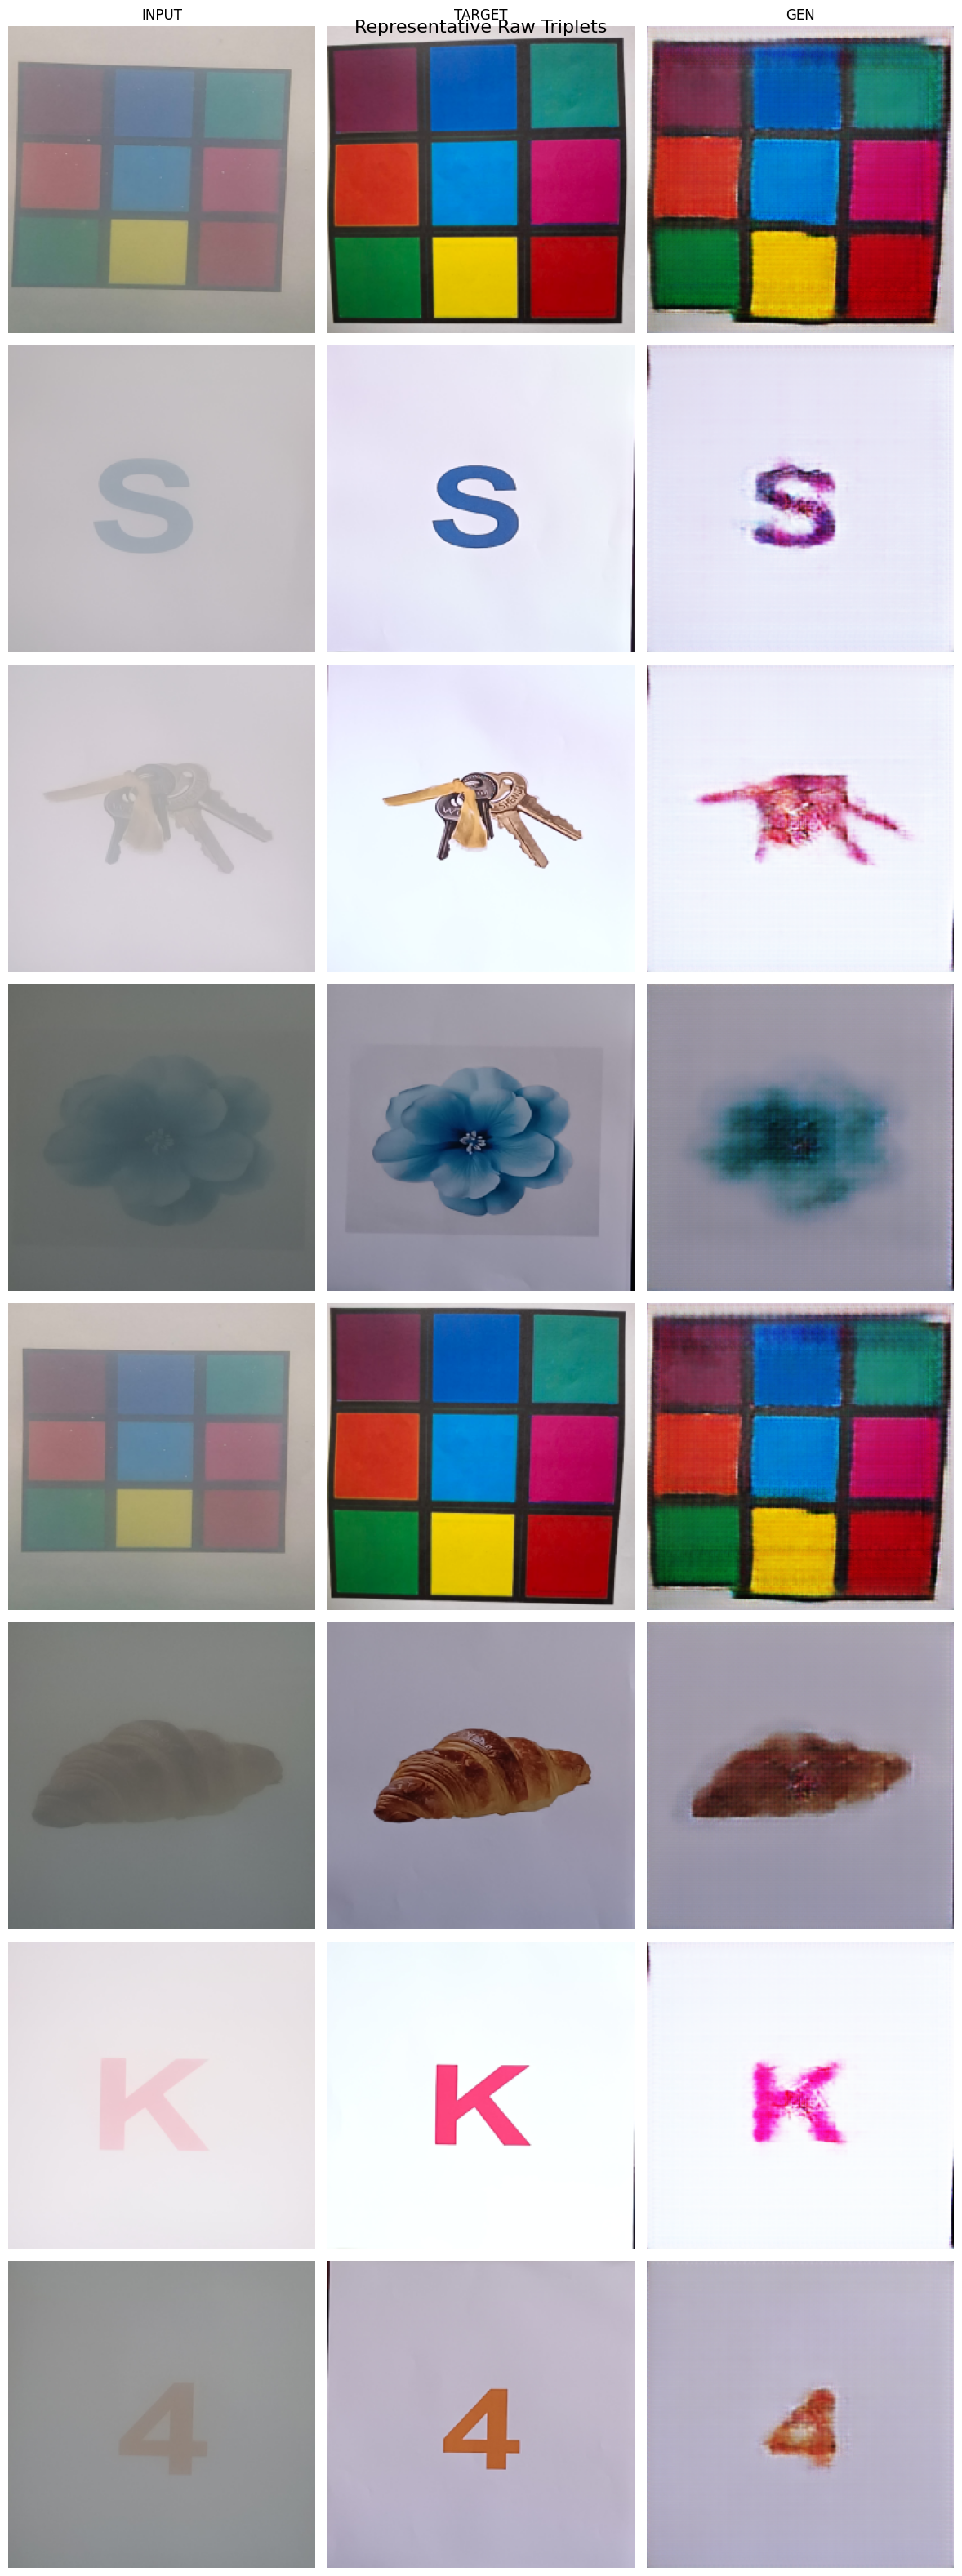

In [19]:
np.random.seed(42)

display_samples = complete_samples.sample(
    min(8, len(complete_samples)),
    random_state=42
)

fig, axes = plt.subplots(
    len(display_samples),
    3,
    figsize=(12, 4 * len(display_samples))
)

if len(display_samples) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, (_, row) in enumerate(display_samples.iterrows()):

    for j, category in enumerate(["input", "target", "gen"]):

        img = Image.open(row[category])

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if i == 0:
            axes[i, j].set_title(category.upper())

    axes[i, 0].set_ylabel(
        f"ID {row['image_id']}",
        fontsize=10
    )

plt.suptitle(
    "Representative Raw Triplets",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "representative_raw_triplets.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [20]:
quality_df["brightness_norm"] = (
    quality_df["brightness"] /
    quality_df["brightness"].max()
)

quality_df["sharpness_norm"] = (
    quality_df["sharpness"] /
    quality_df["sharpness"].max()
)

quality_df["difficulty_score"] = (
    (1 - quality_df["brightness_norm"]) +
    (1 - quality_df["sharpness_norm"])
) / 2

In [21]:
difficult_images = quality_df.sort_values(
    "difficulty_score",
    ascending=False
)

display(
    difficult_images[
        [
            "filename",
            "category",
            "brightness",
            "contrast",
            "sharpness",
            "difficulty_score"
        ]
    ].head(20)
)

,filename,category,brightness,contrast,sharpness,difficulty_score
91,img_146_gen.png,gen,60.556030,67.986416,314.846857,0.839137
801,img_145_gen.png,gen,60.556030,67.986416,314.846857,0.839137
332,img_145_gen.png,gen,60.556030,67.986416,314.846857,0.839137
562,img_146_gen.png,gen,60.556030,67.986416,314.846857,0.839137
855,img_144_gen.png,gen,60.534378,68.043933,316.332437,0.838988
717,img_147_gen.png,gen,60.534378,68.043933,316.332437,0.838988
245,img_147_gen.png,gen,60.534378,68.043933,316.332437,0.838988
387,img_144_gen.png,gen,60.534378,68.043933,316.332437,0.838988
530,img_157_gen.png,gen,64.499695,67.743329,363.133843,0.825065
171,img_156_gen.png,gen,64.499695,67.743329,363.133843,0.825065


In [22]:
difficult_images.head(50).to_csv(
    RESULTS_DIR / "most_difficult_images.csv",
    index=False
)

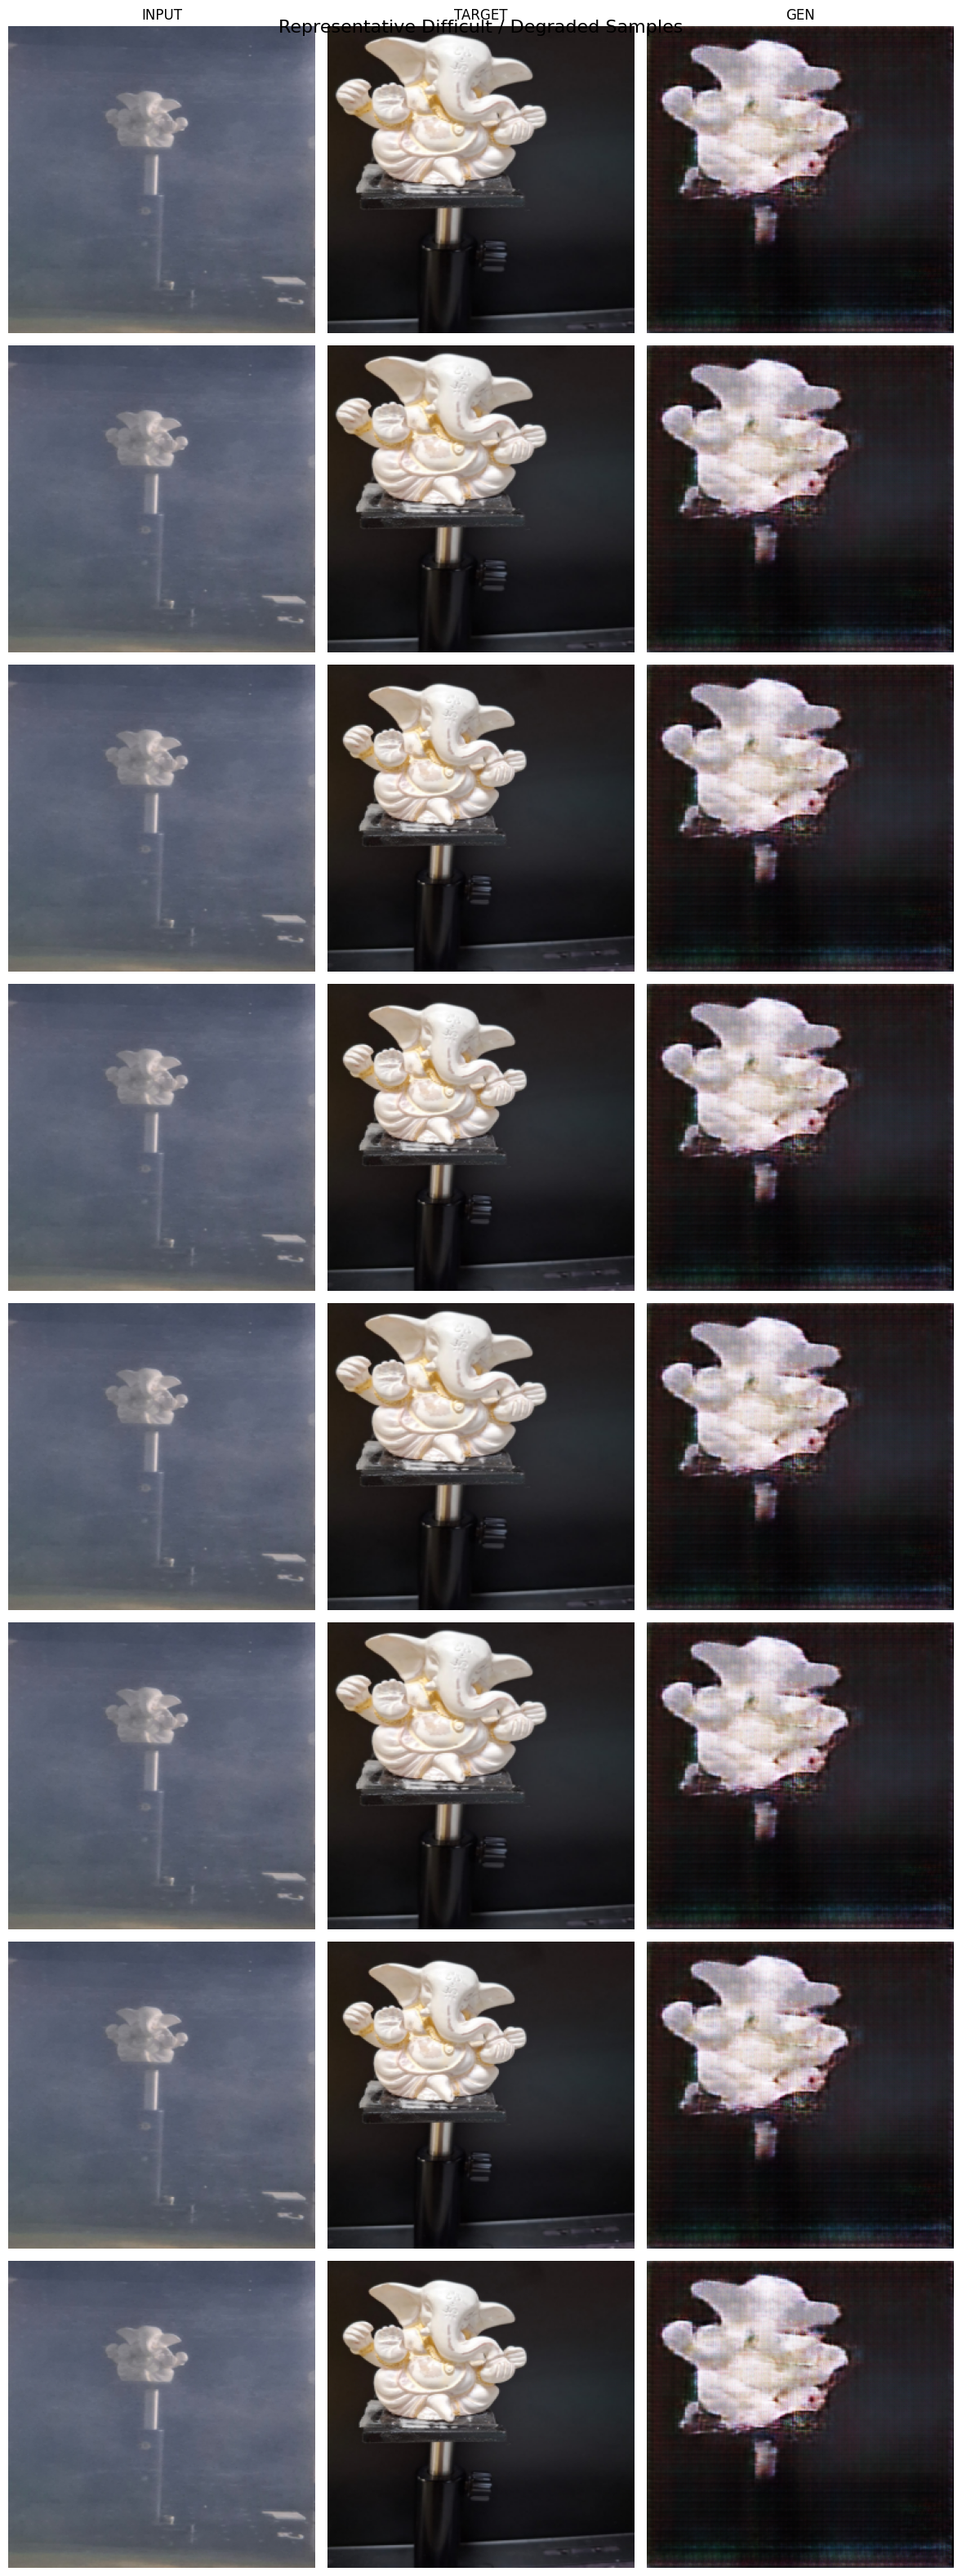

In [23]:
difficult_ids = (
    difficult_images
    .drop_duplicates(["source_archive", "image_id"])
    .head(8)[["source_archive", "image_id"]]
)

difficult_triplets = complete_samples.merge(
    difficult_ids,
    on=["source_archive", "image_id"],
    how="inner"
)

fig, axes = plt.subplots(
    len(difficult_triplets),
    3,
    figsize=(12, 4 * len(difficult_triplets))
)

if len(difficult_triplets) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, (_, row) in enumerate(difficult_triplets.iterrows()):

    for j, category in enumerate(["input", "target", "gen"]):

        img = Image.open(row[category])

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if i == 0:
            axes[i, j].set_title(category.upper())

    axes[i, 0].set_ylabel(
        f"ID {row['image_id']}",
        fontsize=10
    )

plt.suptitle(
    "Representative Difficult / Degraded Samples",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "difficult_sample_grid.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [24]:
dark_threshold = quality_df["brightness"].quantile(0.10)
blur_threshold = quality_df["sharpness"].quantile(0.10)

quality_df["potentially_dark"] = (
    quality_df["brightness"] <= dark_threshold
)

quality_df["potentially_blurry"] = (
    quality_df["sharpness"] <= blur_threshold
)

dark_count = quality_df["potentially_dark"].sum()
blur_count = quality_df["potentially_blurry"].sum()

dark_percentage = dark_count / len(quality_df) * 100
blur_percentage = blur_count / len(quality_df) * 100

print(f"Potentially dark: {dark_count} ({dark_percentage:.2f}%)")
print(f"Potentially blurry: {blur_count} ({blur_percentage:.2f}%)")

Potentially dark: 98 (10.40%)
Potentially blurry: 96 (10.19%)


In [25]:
degradation_by_category = (
    quality_df
    .groupby("category")
    .agg(
        total=("filename", "count"),
        dark=("potentially_dark", "sum"),
        blurry=("potentially_blurry", "sum")
    )
    .reset_index()
)

degradation_by_category["dark_percentage"] = (
    degradation_by_category["dark"] /
    degradation_by_category["total"] * 100
)

degradation_by_category["blurry_percentage"] = (
    degradation_by_category["blurry"] /
    degradation_by_category["total"] * 100
)

display(degradation_by_category)

,category,total,dark,blurry,dark_percentage,blurry_percentage
0,gen,314,46,0,14.649682,0.000000
1,input,314,0,94,0.000000,29.936306
2,target,314,52,2,16.560510,0.636943


In [26]:
degradation_by_category.to_csv(
    RESULTS_DIR / "degradation_by_category.csv",
    index=False
)

In [27]:
hypotheses = """
HYPOTHESES ABOUT DIFFICULT CONDITIONS

1. Low brightness:
Images with low brightness may correspond to poorly illuminated underwater
scenes, deeper environments, or scenes affected by light attenuation.

2. Low contrast:
Low-contrast images may indicate reduced underwater visibility, scattering,
haze, or attenuation of scene details.

3. Low sharpness:
Low sharpness may be associated with motion blur, defocus, poor visibility,
or loss of high-frequency details.

4. Combined degradation:
Images that simultaneously exhibit low brightness and low sharpness may
represent particularly challenging samples for image enhancement.

5. Category differences:
Differences in brightness, contrast, or sharpness between input, target,
and generated images may indicate how the enhancement process changes
visual characteristics.

6. Source/archive imbalance:
If some source archives contain substantially more images than others,
the resulting model may be more influenced by those source groups.

7. Pair consistency:
Although the dataset contains complete input-target-generated triplets,
visual inspection should confirm that the three images correspond to the
same underlying scene and that there are no pairing mistakes.

8. Duplicate content:
The large number of duplicate files detected in Day 1 should be investigated
to determine whether duplicates are intentional copies across image roles,
repeated source images, or actual redundant samples.

IMPORTANT:
These are hypotheses based on measurable image statistics. They should not
be treated as confirmed causes without visual inspection or additional
metadata.
"""

with open(
    RESULTS_DIR / "difficulty_hypotheses.txt",
    "w"
) as f:
    f.write(hypotheses)

print("Saved hypotheses.")

Saved hypotheses.
